<div align="center">
  <h1><b> Quantum Communication and Cryptography </b></h1>
  <h2> Quantum Communication Protocols </h2>
  <h3> Quantum Teleportation </h3>
</div>

<br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera"> Lucas Camponogara Viera</a>

# Table of Contents

- [Theory](#theory)
- [Applications](#applications)
- [Qiskit Implementation](#qiskit-implementation)
- [References](#references)

# Theory

**Goal:** Quantum Teleportation allows Alice to transmit/teleport an arbitrary single-qubit state ($|\psi\rangle=c_1|0\rangle + c_2|1\rangle$) to Bob by using a small overhead of two classical bits of information ($c_1$ and $c_2$), provided they share a pre-established entangled pair.

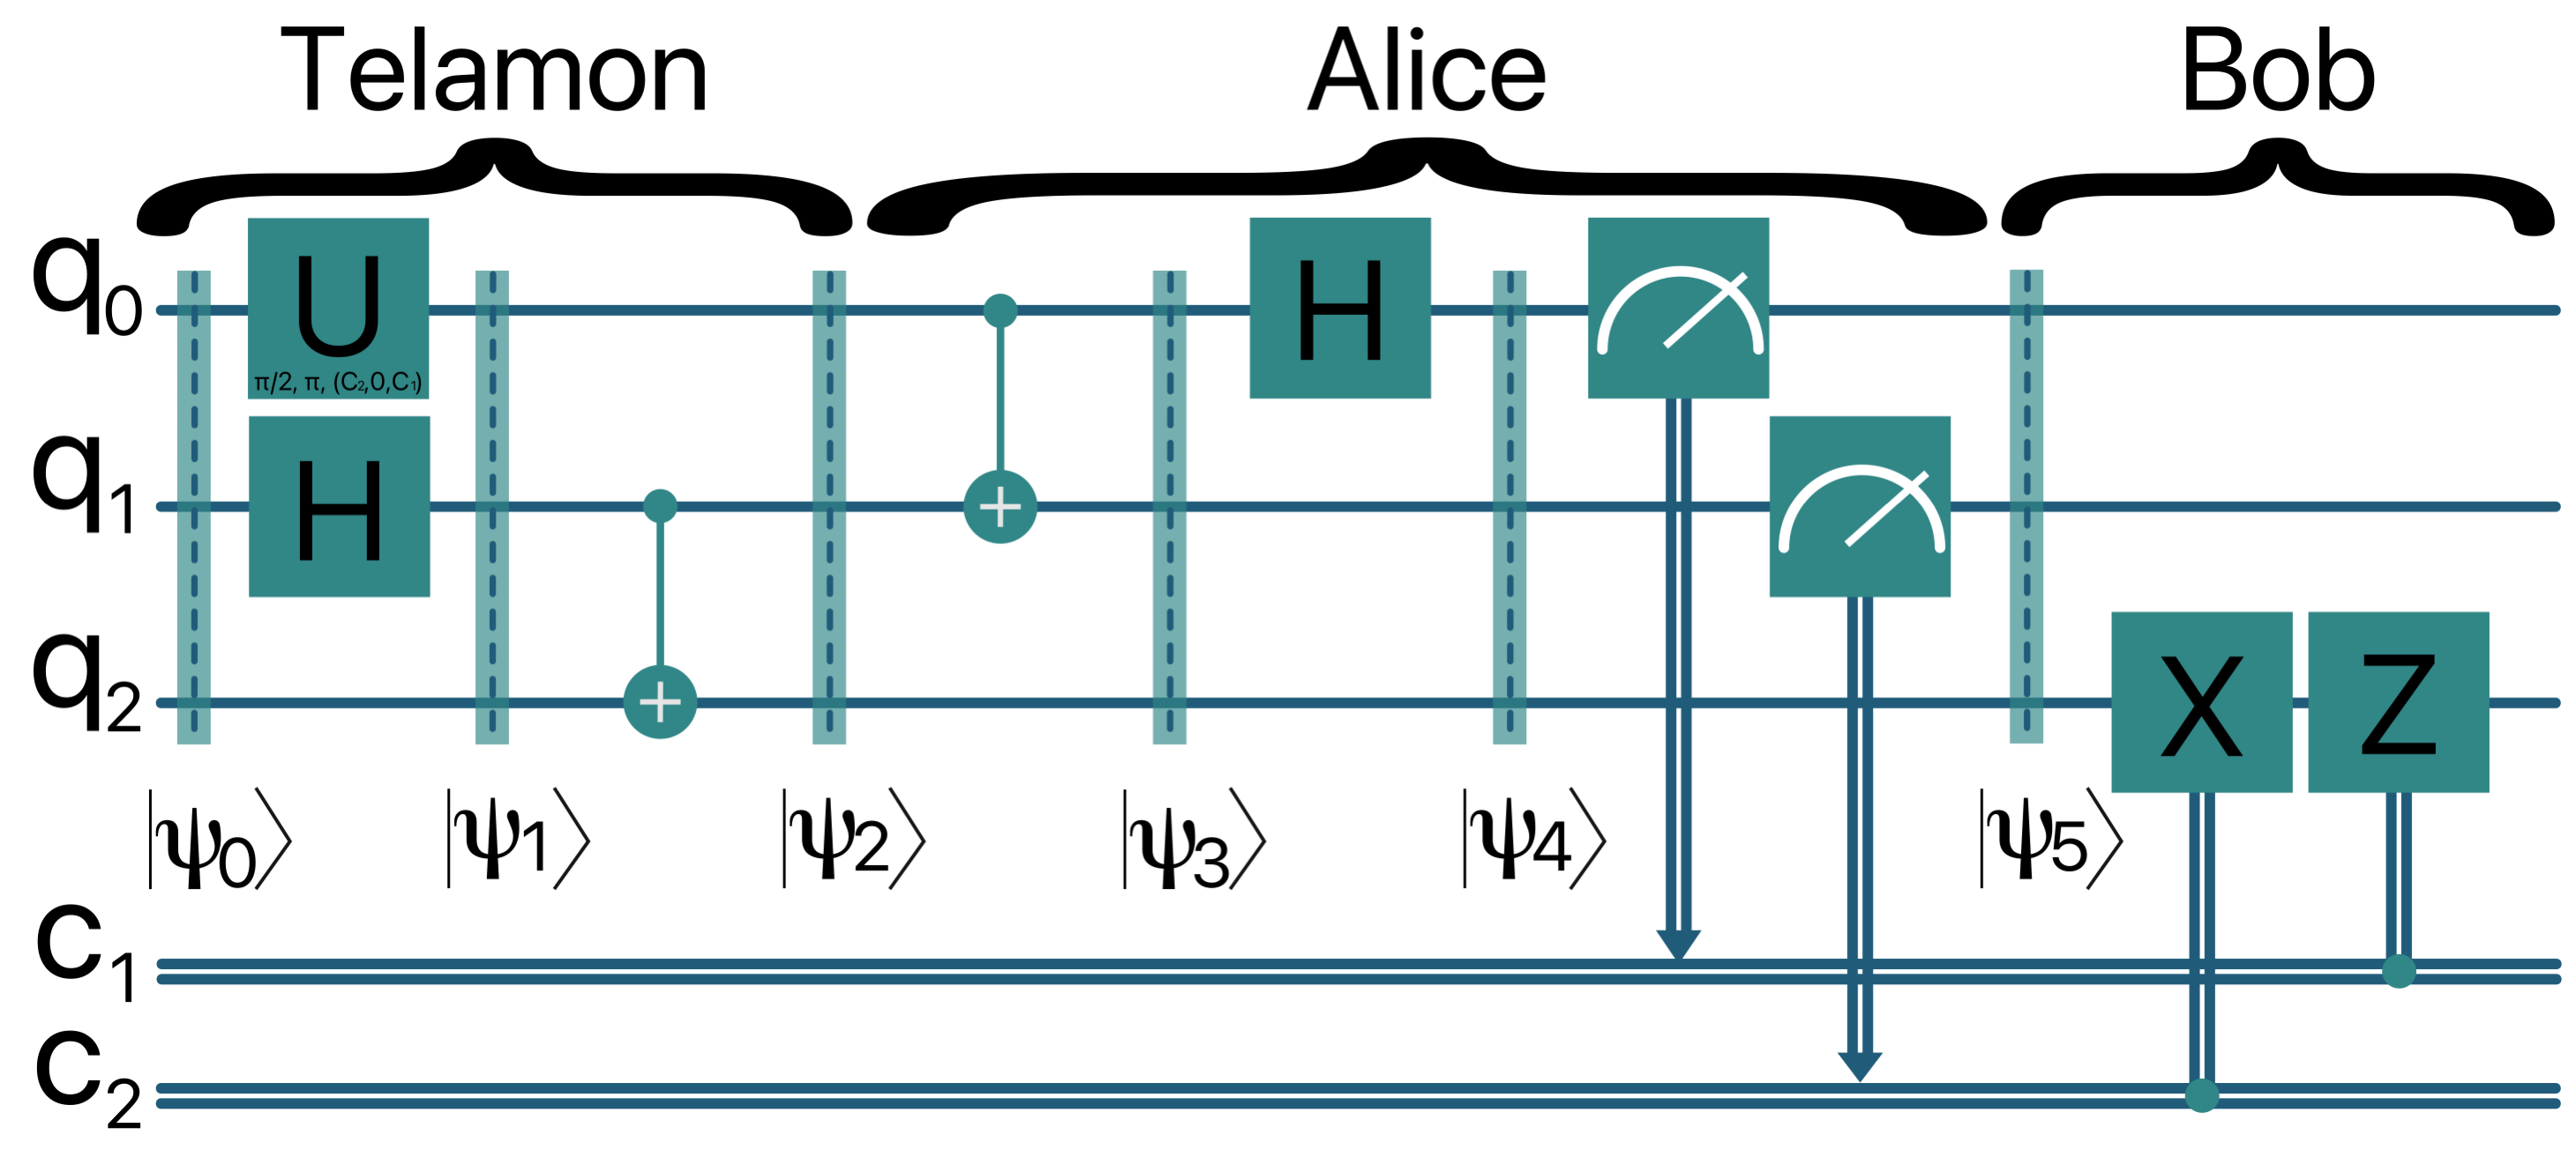

© Image Credits: [QuCAI-Lab](https://github.com/qucai-lab).

**Steps of the protocol:**

1. A third party, named Telamon, prepares a pair of qubits $q_1$ and $q_2$ in a maximally entangled Bell state $|\psi^{Bell}\rangle_{AB}$ and then sends qubit $q_1$ to Alice and qubit $q_2$ to Bob.
2. Alice applies a single-qubit unitary gate $U$ to qubit $q_0$ to prepare the state $|\psi\rangle$.
3. Alice jointly measures the unknown qubit ($q_0$) and her entangled qubit ($q_1$) in the Bell basis (Bell measurement), projecting them into one of four Bell states while destroying the original entanglement between $q_1$ and $q_2$. The act of measurement collapses the Bell state of $q_0$ and $q_1$ into classical bits (cbits) $c_0$ and $c_1$, respectively. 
4. Alice sends the two classical bits to Bob through a classical communication channel.
5. To reconstruct the original state $|\psi\rangle$, Bob applies one of four unitary operations {$\mathbb{I}_d, X, Z, ZX$} on his qubit $q_2$, depending on the classical information (cbits) he receives from Alice. 

Any arbitrary single qubit unitary gate can be written as:

\begin{align}
    U &= e^{i\alpha}R_{\hat{n}}(\theta)=e^{i\alpha} e^{-i\theta \hat{n} \cdot \vec{\sigma}/2}\\
    &=e^{i\alpha} \left(cos\left(\frac{\theta}{2}\right)\mathbb{I}_2-sin\left(\frac{\theta}{2}\right)(\hat{n}\cdot \vec{\sigma})\right),
\end{align}

given $a$ and $\theta \in \mathbb{R}$, $i^2=-1$, 3-dimensional unit vector $\hat{n}=(n_x, n_y, n_z)$, and three component vector $\vec{\sigma}=(X, Y, Z)$. 

A random 1-qubit state then reads:

\begin{align}
|\psi\rangle = \left(e^{i(\frac{\pi}{2})}R_{(c_2, 0, c_1)}(\pi)\right)|0\rangle = c_1 |0\rangle+ c_2 |1\rangle.
\end{align}

The evolution of the quantum state of the system throughout the circuit is given as follows:

- Each qubit in a real quantum computer is initialized in the ground state $|0\rangle$. The initial global state of the composite tripartite system is, therefore:

\begin{align}
    |\psi_0\rangle = |0\rangle \otimes |0\rangle \otimes |0\rangle \doteq |000\rangle.
\end{align}

- Telamon then applies a Hadamard gate to qubit $q_1$, while qubit $q_0$ is owned by Alice:

\begin{align}
U|0\rangle&= |\psi\rangle=c_1|0\rangle + c_2|1\rangle,\\
H|0\rangle&=|+\rangle=\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle,\\
    |\psi_1\rangle &=(U\otimes H\otimes \mathbb{I})|\psi_0\rangle\\
    &=U|0\rangle \otimes H|0\rangle \otimes |0\rangle\\
    &=|\psi\rangle\otimes |+\rangle \otimes |0\rangle\\
    &=|\psi\rangle\otimes\left(\frac{|0\rangle+ |1\rangle}{\sqrt{2}} \otimes |0\rangle\right)\\
    &=|\psi\rangle\otimes\left(\frac{|00\rangle+|10\rangle}{\sqrt{2}} \right)\\
    &= \frac{c_1|000\rangle+c_2|100\rangle+c_1|010\rangle+c_2|110\rangle}{\sqrt{2}}.
\end{align}

- The following cNOT gate applied to qubit $q_2$ (target) controlled by $q_1$ creates an entangled Bell state. The action of the cNOT gate is to flip the target qubit (the rightmost qubit) if the control (the leftmost qubit) is $|1\rangle$:
  
\begin{align}
    cNOT\bigg(|+\rangle \otimes |0\rangle\bigg)
    &= cNOT\left(\frac{|00\rangle+|10\rangle}{\sqrt{2}}\right)\\ &=\frac{|00\rangle+|11\rangle}{\sqrt{2}} \\&\doteq |e\rangle,
\end{align}

and the global state of the system updates to

\begin{align}
    |\psi_2\rangle&= (\mathbb{I}_2 \otimes cNOT)|\psi_1\rangle\\
    &=(\mathbb{I}_2 \otimes cNOT)(|\psi\rangle\otimes |+\rangle \otimes |0\rangle)\\
    &= |\psi\rangle \otimes cNOT\bigg(|+\rangle \otimes |0\rangle\bigg)\\
    &= |\psi\rangle \otimes |e\rangle\\
    &= \frac{c_1|000\rangle+c_1|011\rangle+c_2|100\rangle+c_2|111\rangle}{\sqrt{2}}.
\end{align}

- On her turn, Alice applies a cNOT gate on qubit $q_1$ (target) controlled by $q_0$. From left to right, the first qubit is the control and the second is the target, whereas the third remains unchanged:
  
\begin{align}
    |\psi_3\rangle &= (cNOT \otimes \mathbb{I}_2)|\psi_2\rangle\\
    &=\frac{c_1|000\rangle+c_1|011\rangle+c_2|110\rangle+c_2|101\rangle}{\sqrt{2}}.
\end{align}

- Alice then applies a Hadamard gate to $q_0$:
  
\begin{align}
    |\psi_4\rangle &= (H\otimes\mathbb{I}_2\otimes\mathbb{I}_2)|\psi_3\rangle\\
    &=(H\otimes\mathbb{I}_2\otimes\mathbb{I}_2)(cNOT \otimes \mathbb{I}_2)(|\psi\rangle \otimes |e\rangle)\\
    &=\frac{1}{2}\bigg\{c_1\bigg(|000\rangle+|011\rangle+|100\rangle+|111\rangle\bigg)\\
    &+c_2\bigg(|010\rangle+|001\rangle-|110\rangle-|101\rangle\bigg)\bigg\}\\
    &=\frac{1}{2}\bigg\{
    |00\rangle_a\otimes\bigg(c_1|0\rangle_b+c_2|1\rangle_b\bigg)\\
    &+|01\rangle_a\otimes\bigg(c_1|1\rangle_b+c_2|0\rangle_b\bigg)\\
    &+|10\rangle_a\otimes\bigg(c_1|0\rangle_b-c_2|1\rangle_b\bigg)\\
    &+|11\rangle_a\otimes\bigg(c_1|1\rangle_b-c_2|0\rangle_b\bigg)
    \bigg\}\\
    &=\frac{1}{2}\bigg\{|00\rangle_a \otimes \mathbb{I}_2|\psi\rangle + |01\rangle_a \otimes X|\psi\rangle \\
    &+|10\rangle_a \otimes Z|\psi\rangle + |11\rangle_a \otimes XZ|\psi\rangle\bigg\}.
\end{align}

- Upon measurement in the computational basis $(M_{ja}\otimes M_{ia} \otimes \mathbb{I}_2)|\psi_4\rangle$, Alice's subsystem of two qubits denoted $a$ collapses to one of the four classical states, as does Bob's subsystem. The global state of the tripartite system thus becomes one of the following states, each occurring with probability $1/4$:
  
\begin{align}
    |\psi_5\rangle_{ab} = |00\rangle_a\otimes\bigg(c_1|0\rangle_b+c_2|1\rangle_b\bigg),\\
    |\psi_5\rangle_{ab} = |01\rangle_a\otimes\bigg(c_1|1\rangle_b+c_2|0\rangle_b\bigg),\\
    |\psi_5\rangle_{ab} = |10\rangle_a\otimes\bigg(c_1|0\rangle_b-c_2|1\rangle_b\bigg),\\
    |\psi_5\rangle_{ab} = |11\rangle_a\otimes\bigg(c_1|1\rangle_b-c_2|0\rangle_b\bigg).
\end{align}

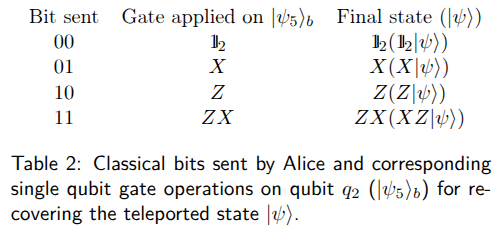

© Image Credits: [QuCAI-Lab](https://github.com/qucai-lab).

Bennet __et al.__ proved that perfect quantum communication requires at least two maximally entangled qubits. However, open quantum systems are prone to noise processes such as thermalization and dephasing which causes the quantum system to rapidly lose coherent information. In this scenario, 2-qubit maximally entangled pure states (Bell states) are often unavailable, while non-maximal Bell states are insufficient for realization of perfect quantum teleportation and perfect superdense coding. 

A workaround is to use a noise-resilient class of states such as the special class of $GHZ$-like and $W$-like maximally entangled tripartite states. Particularly, $W$-like states form a more robust class that can be used even after particle loss. In spite of that, the requirement of non-local operations in quantum communication protocols restricts the aforementioned $w$-like state to only imperfect quantum teleportation and imperfect superdense coding schemes. 

In 2006, Agrawal __et al.__ showed that a class of 3-qubit $W$-like nonmaximally entangled states meet the criteria for both perfect teleportation and superdense coding. For a generalization of the scheme to higher dimensions, the reader may resort to [5].

# Applications

Quantum Teleportation can be used:

1. As a resource for 1-qubit communication. 

2. To implement two-qubit quantum gates (e.g., CNOT) in the [KLM protocol](https://en.wikipedia.org/wiki/KLM_protocol).
   
3. To build noise-resilient (fault-tolerant) **non-transversal quantum gates** via [gate teleportation](https://en.wikipedia.org/wiki/Quantum_gate_teleportation) [3].

    - In fault-tolerant quantum computation, the goal is to implement gates on logical qubits in a way that prevents errors from spreading across physical qubits. This is usually done using **transversal gates** because they limit error propagation across a code block on a error correcting code.
    
    - However, the [Eastin-Knill theorem](https://en.wikipedia.org/wiki/Eastin%E2%80%93Knill_theorem) states that no quantum error correcting code (QECC) admits a universal set of logical gates that can all be implemented transversally. One example is the [Steane code](https://en.wikipedia.org/wiki/Steane_code) that does not allow transversal implementation of the $T$ gate. As a result, transversal gates alone on a fixed code are insufficient for universal quantum computation.
    
    - Techniques such as [gate teleportation](https://en.wikipedia.org/wiki/Quantum_gate_teleportation) (used in the [magic state injection](https://pennylane.ai/qml/glossary/what-are-magic-states) protocol) can be used to overcome the limitations imposed by Eastin-Knill theorem. The protocol of quantum gate teleportation uses **ancillary/resource state preparation** (e.g., Bell pairs or magic states), **Bell measurement**, **classical communication of measurement outcomes**, and **conditional single-qubit correction operations** (e.g., Clifford gates) to implement non-transversal logical gates (e.g., the T gate) fault-tolerantly.

# Qiskit Implementation

In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_multivector
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator

from IPython.display import display
import matplotlib.pyplot as plt
import ipywidgets as widgets
from PIL import Image

Quantum Circuit for the Teleportation Protocol:


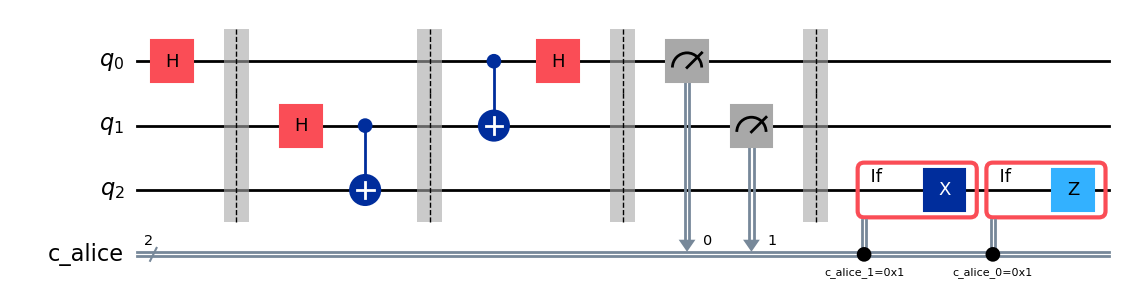

In [3]:
qr_tele = QuantumRegister(3, name='q') # q0 (Alice's state), q1 (Alice's half of the Bell pair), q2 (Bob's half).
cr_alice_tele = ClassicalRegister(2, name='c_alice') # Classical register to store Alice's measurements.
teleport_qc = QuantumCircuit(qr_tele, cr_alice_tele, name='Teleportation') # The quantum circuit for the protocol.

# Alice prepare the state (|ψ>=|+>) she wants to teleport on q0:
teleport_qc.h(qr_tele[0]) # Apply H gate to q0.
teleport_qc.barrier() # Add a barrier for visual separation.

# Step 1: Telamon creates a maximally entangled Bell pair between q1 (Alice) and q2 (Bob):
teleport_qc.h(qr_tele[1]) # Apply H gate to q1.
teleport_qc.cx(qr_tele[1], qr_tele[2]) # Apply CNOT with q1 as control and q2 as target.
teleport_qc.barrier() 

# Step 2: Alice perform a Bell Measurement on q0 and q1:
teleport_qc.cx(qr_tele[0], qr_tele[1]) # Apply CNOT with q0 as control and q1 as target.
teleport_qc.h(qr_tele[0]) # Apply H gate to q0.
teleport_qc.barrier() 

# Alice measures her qubits q0 and q1 and stores the results in classical bits c0 and c1:
teleport_qc.measure(qr_tele[0], cr_alice_tele[0]) # Measure q0 and store the result in c0.
teleport_qc.measure(qr_tele[1], cr_alice_tele[1]) # Measure q1 and store the result in c1.
teleport_qc.barrier()

# Step 3: Bob applies conditional operations on q2 based on Alice's measurement results:

with teleport_qc.if_test((cr_alice_tele[1], 1)):
    teleport_qc.x(qr_tele[2]) # If c1 == 1, apply X gate to q2.

with teleport_qc.if_test((cr_alice_tele[0], 1)):
    teleport_qc.z(qr_tele[2]) # If c0 == 1, apply Z gate to q2.
    
print("Quantum Circuit for the Teleportation Protocol:")
display(teleport_qc.draw('mpl'))

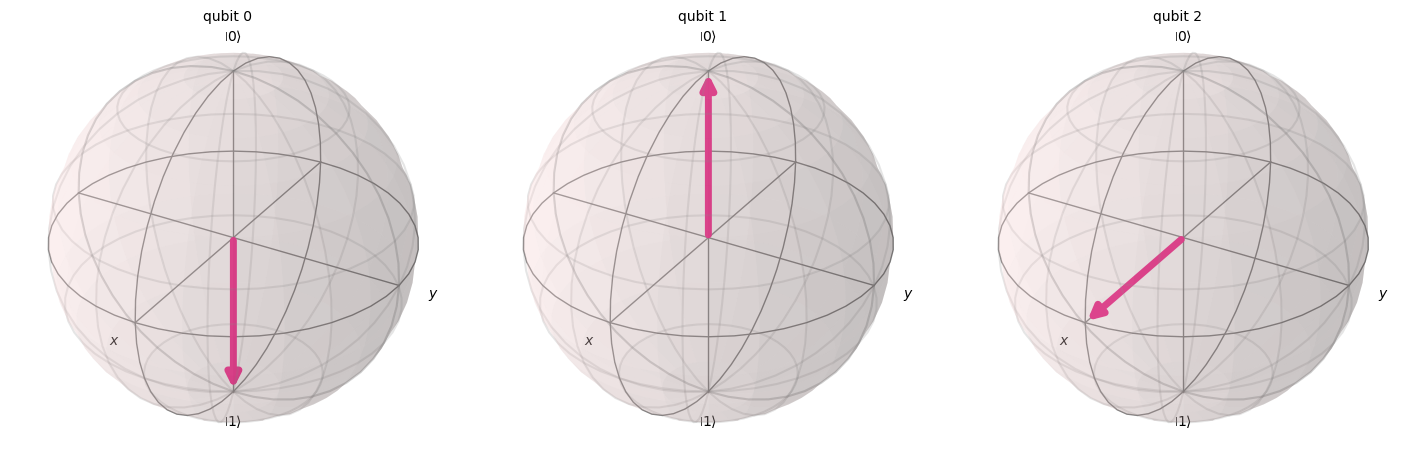

In [18]:
%matplotlib inline

simulator = AerSimulator(method='statevector') # Using statevector simulator backend to get the final quantum statevector.
teleport_qc_copy = teleport_qc.copy() # Create a copy of the circuit for statevector simulation.
teleport_qc_copy.save_statevector() # Save the current statevector for simulation.

# Run the statevector simulation:
job = simulator.run(teleport_qc_copy, shots=1024) # Submit the job to the simulator with 1024 number of shots.
result = job.result() # Get the results from the job.

if result.success:
    final_statevector = result.get_statevector() # Extract the final statevector.
    bloch_plot = plot_bloch_multivector(final_statevector) # Plot the Bloch sphere representation of the final statevector.
    plt.show()
        
else:
    print(f"Statevector simulation failed! Status: {result.status}")

- One can see that the state of qubit `q2` (Bob's qubit) after the teleportation protocol is now |+>, matching the initial state of qubit `q0` (Alice's qubit), confirming successful quantum teleportation.

- The state of qubits `q0` and `q1` (Alice's qubits) collapse to one of the four classical states after measurement, as expected.

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

[1] Nielsen, M. A., &#38; Chuang, I. L. (2010). Quantum Computation and Quantum Information: 10th Anniversary Edition. Cambridge: Cambridge University Press. https://doi.org/10.1017/CBO9780511976667

[2] Gottesman, D. and Chuang, I. L. (1999). Quantum teleportation is a universal computational primitive. [arXiv preprint arXiv:quant-ph/9908010](https://arxiv.org/abs/quant-ph/9908010). 

[3] Qiskit Global Summer School 2025, https://github.com/qiskit-community/qgss-2025/tree/main?tab=readme-ov-file.

[4] Li, L. and Qiu, D. (2007). The states of W-class as shared resources for perfect teleportation and superdense coding. [arXiv:quant-ph/0701030](https://arxiv.org/abs/quant-ph/0701030). 

[5] https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/entanglement-in-action/quantum-teleportation.